In [ ]:
# SIGNAL PROCESSING Feature engineering
# Right-Hemisphere M1 Hand Knob
# 
# Pipeline Steps:
# 1. IIR High-pass (1 Hz) & Low-pass (100 Hz)
# 2. FIR Notch Filter (60 Hz line noise removal)
# 3. Z-score Normalization
# 4. Spectral Analysis (PSD & Spectrogram)
# 5. Save Processed Data
# 6. Epoching (1.5s windows, 75% overlap)
# 7. Frequency Band Feature Extraction (Pandas DataFrames)

In [89]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.autolayout': True,
})

# Configuration
DATA_DIR  = Path("./extracted_raw_time_series")
OUTPUT_DIR = Path("./processed_data")
OUTPUT_DIR.mkdir(exist_ok=True)

FS = 500.0   # Sampling rate (Hz) - No decimation applied

def get_frequency_bands():
    return {
        "delta": (1, 4),
        "theta": (4, 8),
        "alpha": (8, 12), 
        "beta": (13, 30),
        "low_gamma": (30, 50), 
        "high_gamma": (50, 100)
    }


In [90]:
# Load data
print("Loading raw data...")
rest_raw = np.load(DATA_DIR / "R_M1_hand_knob_voxel_EyesClosed_Rest.npy")
move_raw = np.load(DATA_DIR / "R_M1_hand_knob_voxel_LeftHand_Move.npy")

print(f"Rest: {len(rest_raw)} samples ({len(rest_raw)/FS:.1f} s)")
print(f"Move: {len(move_raw)} samples ({len(move_raw)/FS:.1f} s)")

Loading raw data...
Rest: 7500 samples (15.0 s)
Move: 7500 samples (15.0 s)


In [91]:
# STEP 1: IIR FILTERING (High-Pass & Low-Pass)
# Applying separate High-Pass (1 Hz) and Low-Pass (50 Hz) Butterworth filters.
# Using `sosfiltfilt` for zero-phase filtering.

def apply_iir_bandpass(signal_data, fs, low_cut=1.0, high_cut=100.0, order=4):
    nyq = 0.5 * fs
    
    # 1. High-Pass Filter (remove DC drift and slow fluctuations)
    hp_wn = low_cut / nyq
    hp_sos = signal.butter(order, hp_wn, btype='highpass', output='sos')
    filtered_hp = signal.sosfiltfilt(hp_sos, signal_data)
    
    # 2. Low-Pass Filter (remove high-frequency noise/aliasing)
    lp_wn = high_cut / nyq
    lp_sos = signal.butter(order, lp_wn, btype='lowpass', output='sos')
    filtered_lp = signal.sosfiltfilt(lp_sos, filtered_hp)
    
    return filtered_lp

# Apply to both conditions
rest_filt = apply_iir_bandpass(rest_raw, FS)
move_filt = apply_iir_bandpass(move_raw, FS)

print("[IIR Filtering] Applied HP (1 Hz) and LP (50 Hz)")

# STEP 2: FIR NOTCH FILTER
# Removing specific line noise (50 Hz) using a FIR filter designed with `firwin`.

def apply_fir_notch(signal_data, fs, notch_freq=50.0, width=2.0, numtaps=101):
    """
    Applies a FIR band-stop (notch) filter.
    """
    nyq = 0.5 * fs
    # Define the stop band edges
    low = (notch_freq - width/2) / nyq
    high = (notch_freq + width/2) / nyq
    
    # Ensure frequencies are within valid range (0, 1)
    if low <= 0: low = 0.001
    if high >= 1: high = 0.999
    
    # Design FIR filter (Band-stop)
    # pass_zero=True with two cutoffs creates: Pass[0-low], Stop[low-high], Pass[high-Nyq]
    taps = signal.firwin(numtaps, [low, high], pass_zero=True, fs=fs)
    
    # Apply filter (zero-phase)
    filtered_notch = signal.filtfilt(taps, 1.0, signal_data)
    return filtered_notch

# Apply Notch Filter (Targeting 50 Hz line noise)
# Width of 2 Hz means removing 49-51 Hz
rest_final = apply_fir_notch(rest_filt, FS, notch_freq=60.0, width=1.0)
move_final = apply_fir_notch(move_filt, FS, notch_freq=60.0, width=1.0)

print("[FIR Notch] Applied 50 Hz Notch Filter")

[IIR Filtering] Applied HP (1 Hz) and LP (50 Hz)
[FIR Notch] Applied 50 Hz Notch Filter


[Z-Score] Normalization complete.


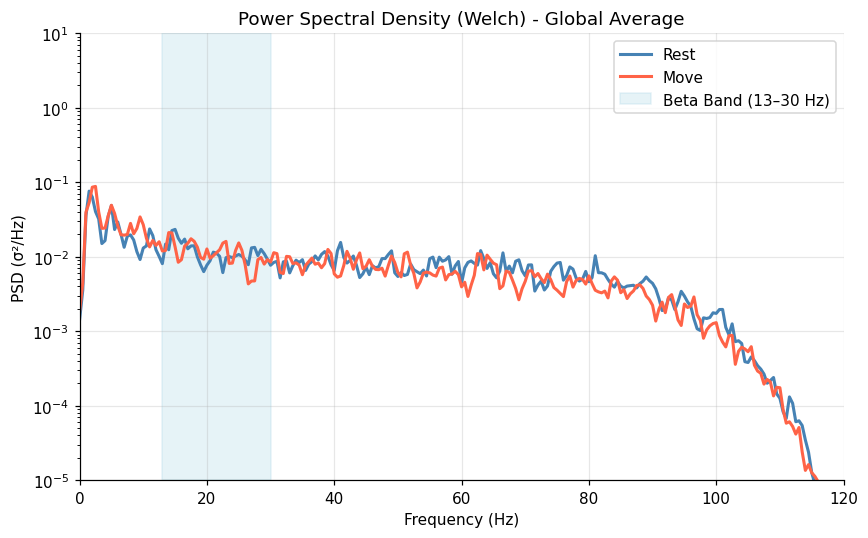

In [92]:
# STEP 3: Z-SCORE NORMALIZATION
# Standardizing the signal to mean=0, std=1.

def zscore(sig_in):
    mu = np.mean(sig_in)
    sigma = np.std(sig_in)
    if sigma < 1e-12:
        return sig_in
    return (sig_in - mu) / sigma

rest_z = zscore(rest_final)
move_z = zscore(move_final)

print("[Z-Score] Normalization complete.")

# STEP 4: FOURIER ANALYSIS (Welch's PSD) - Global View

nperseg = int(FS * 2)   # 2-second windows
noverlap = nperseg // 2        # 50% overlap

freqs_r, psd_rest = signal.welch(rest_z, FS, nperseg=nperseg, noverlap=noverlap, window='hann')
freqs_m, psd_move = signal.welch(move_z, FS, nperseg=nperseg, noverlap=noverlap, window='hann')

plt.figure(figsize=(8, 5))
plt.semilogy(freqs_r, psd_rest, color='steelblue', lw=2, label='Rest')
plt.semilogy(freqs_m, psd_move, color='tomato',    lw=2, label='Move')
plt.axvspan(13, 30, color='lightblue', alpha=0.30, label='Beta Band (13–30 Hz)')
plt.xlim(0, 120)
plt.yscale('log')
plt.ylim(0.00001, 10)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (σ²/Hz)")
plt.title("Power Spectral Density (Welch) - Global Average")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

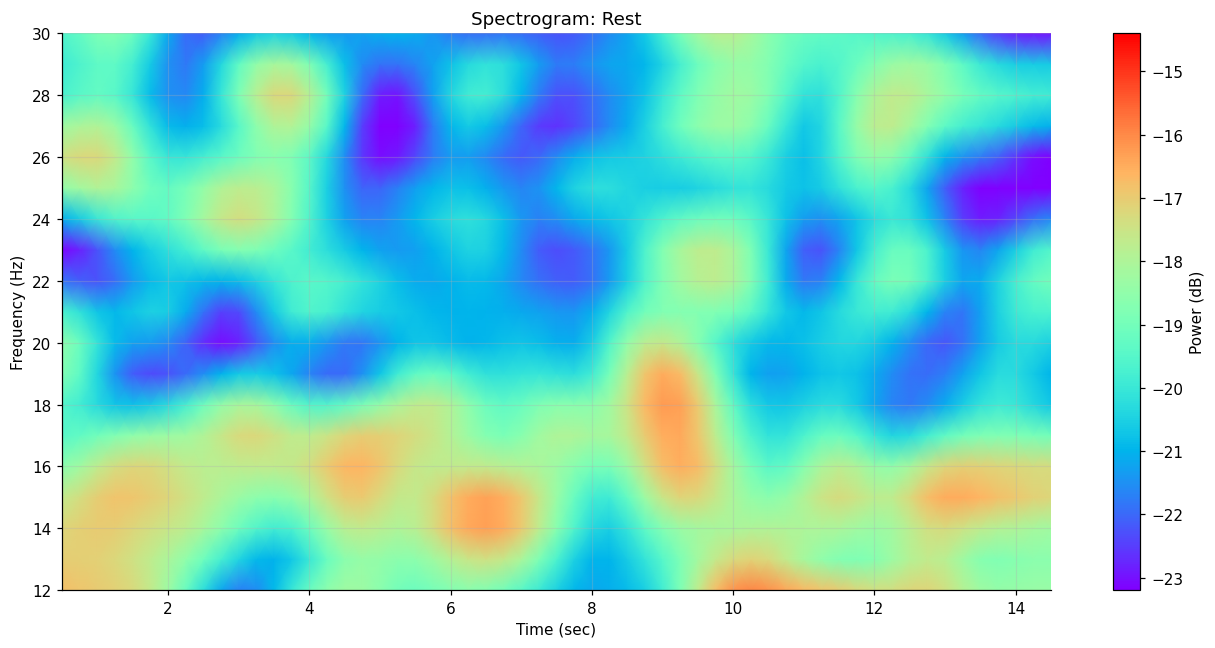

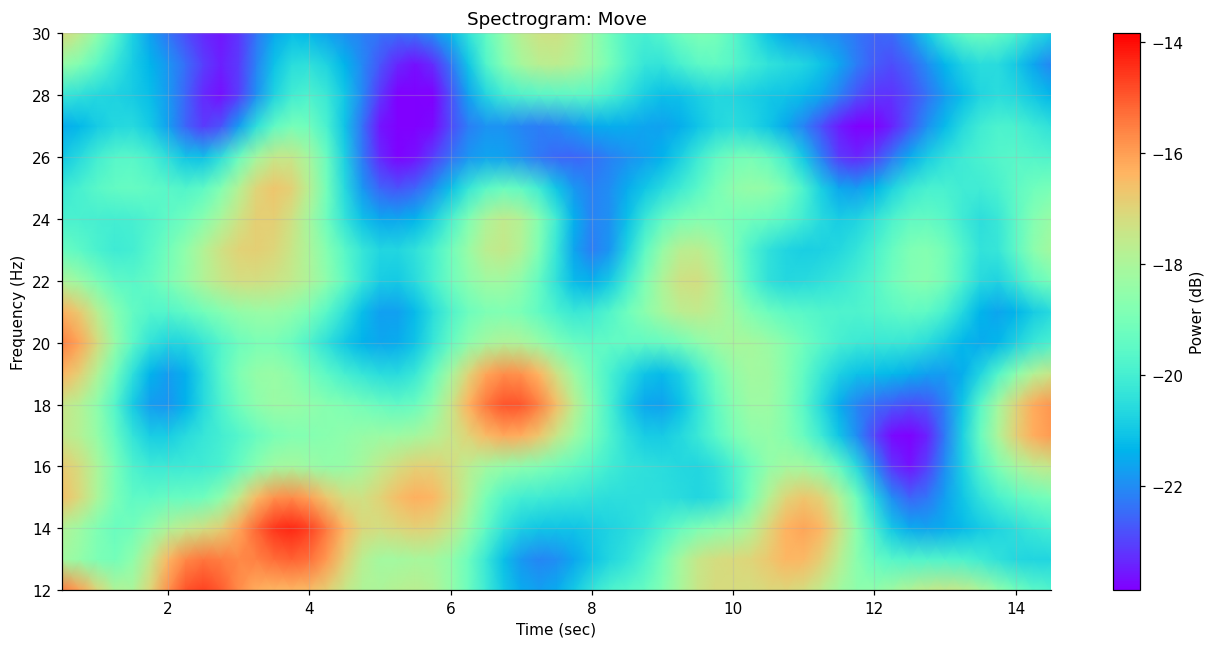

In [93]:
# STEP 5: BETA BAND SPECTROGRAM

from scipy.ndimage import gaussian_filter

def smooth_spectrogram(Sxx, sigma=(1.0, 1.0)):
    return gaussian_filter(Sxx, sigma=sigma)

def plot_spectrogram(sig, fs, title):
    nperseg = int(fs * 1.0)  # 1-second window
    noverlap = int(nperseg * 0.75) 
    
    f, t, Sxx = signal.spectrogram(sig, fs, nperseg=nperseg, noverlap=noverlap, window='hann')
    Sxx_smooth = smooth_spectrogram(Sxx, sigma=(1.0, 2.0))
    Sxx_db = 10 * np.log10(Sxx_smooth + 1e-12)
    
    vmin = np.percentile(Sxx_db, 70)
    vmax = np.percentile(Sxx_db, 99)
    
    plt.figure(figsize=(12, 6))
    mesh = plt.pcolormesh(t, f, Sxx_db, shading='gouraud', cmap='rainbow', vmin=vmin, vmax=vmax)
    plt.ylim([12, 30])
    plt.ylabel('Frequency (Hz)')
    plt.xlabel('Time (sec)')
    plt.title(title)
    plt.colorbar(mesh, label='Power (dB)')
    plt.tight_layout()
    plt.show()

plot_spectrogram(rest_z, FS, "Spectrogram: Rest")
plot_spectrogram(move_z, FS, "Spectrogram: Move")

In [94]:
# STEP 6: SAVE PROCESSED CONTINUOUS DATA

# np.save(OUTPUT_DIR / "R_M1_hand_knob_Rest_Processed.npy", rest_z)
# np.save(OUTPUT_DIR / "R_M1_hand_knob_Move_Processed.npy", move_z)

print("\nContinuous data saved.")


Continuous data saved.


In [95]:
# ==============================================================================
# STEP 7: EPOCHING (2 Seconds, 75% Overlap)
# ==============================================================================

def create_epochs(signal_data, fs, epoch_duration=2.0, overlap_frac=0.75):
    """
    Splits signal into overlapping epochs.
    Returns a list of arrays, each of shape (epoch_samples,)
    """
    epoch_samples = int(epoch_duration * fs)
    step_size = int(epoch_samples * (1 - overlap_frac))
    
    epochs = []
    start_idx = 0
    
    while start_idx + epoch_samples <= len(signal_data):
        end_idx = start_idx + epoch_samples
        epochs.append(signal_data[start_idx:end_idx])
        start_idx += step_size
        
    return epochs

print("Creating epochs (2s duration, 75% overlap)...")
rest_epochs = create_epochs(rest_z, FS, epoch_duration=1.5, overlap_frac=0.75)
move_epochs = create_epochs(move_z, FS, epoch_duration=1.5, overlap_frac=0.75)

print(f"Rest epochs: {len(rest_epochs)}")
print(f"Move epochs: {len(move_epochs)}")


Creating epochs (2s duration, 75% overlap)...
Rest epochs: 37
Move epochs: 37


In [96]:
# ==============================================================================
# STEP 8: FREQUENCY BAND FEATURE EXTRACTION
# ==============================================================================

def compute_epoch_features(epochs, fs, freq_bands):
    """
    Computes power in specific frequency bands for each epoch using Welch's method.
    Returns a Pandas DataFrame.
    """
    nperseg = len(epochs[0]) # Use full epoch length for FFT resolution
    noverlap = nperseg // 2
    
    feature_list = []
    
    # Get all band names for column ordering
    band_names = list(freq_bands.keys())
    
    for i, epoch in enumerate(epochs):
        # Compute PSD for this single epoch
        freqs, psd = signal.welch(epoch, fs, nperseg=nperseg, noverlap=noverlap, window='hann')
        
        features = {'epoch': i}
        
        for band_name, (low_freq, high_freq) in freq_bands.items():
            # Find indices corresponding to the frequency band
            idx_band = np.logical_and(freqs >= low_freq, freqs <= high_freq)
            
            # Integrate PSD over the band (sum of power * frequency resolution)
            # Note: sum(psd[idx]) * df approximates the power in that band
            if np.any(idx_band):
                band_power = np.trapz(psd[idx_band], freqs[idx_band])
            else:
                band_power = 0.0
                
            features[band_name] = band_power
            
        feature_list.append(features)
        
    df = pd.DataFrame(feature_list, columns=['epoch'] + band_names)
    return df



In [97]:
# Define bands
bands = get_frequency_bands()


In [98]:
# Process Rest
print("Computing features for Rest...")
df_rest = compute_epoch_features(rest_epochs, FS, bands)

Computing features for Rest...


In [99]:
# Process Move
print("Computing features for Move...")
df_move = compute_epoch_features(move_epochs, FS, bands)


Computing features for Move...


In [100]:
# Display Head
print("\n--- Rest Features Head ---")
df_rest.head()


--- Rest Features Head ---


,epoch,delta,theta,alpha,beta,low_gamma,high_gamma
0,0,0.090291,0.063766,0.064028,0.208782,0.132257,0.213860
1,1,0.136005,0.049443,0.073702,0.253173,0.191476,0.271837
2,2,0.132776,0.061914,0.112663,0.183615,0.165175,0.311834
3,3,0.077954,0.053217,0.042348,0.178087,0.142505,0.275516
4,4,0.094573,0.045558,0.020482,0.164114,0.179896,0.310945


In [101]:
print("\n--- Move Features Head ---")
df_move.head()


--- Move Features Head ---


,epoch,delta,theta,alpha,beta,low_gamma,high_gamma
0,0,0.039555,0.140413,0.183223,0.263241,0.200818,0.223191
1,1,0.208233,0.125232,0.086161,0.154062,0.154183,0.250966
2,2,0.131367,0.225779,0.042304,0.139490,0.101924,0.234042
3,3,0.103614,0.120805,0.037328,0.167171,0.081312,0.254204
4,4,0.186833,0.045042,0.109726,0.148717,0.099774,0.320408


In [102]:
# Save DataFrames
# df_rest.to_csv(OUTPUT_DIR / "R_M1_hand_knob_Rest_Features.csv", index=False)
# df_move.to_csv(OUTPUT_DIR / "R_M1_hand_knob_Move_Features.csv", index=False)


In [103]:
# STEP 9: MERGE DATAFRAMES AND ADD TARGET LABEL

# Add 'target' column to each DataFrame
df_rest['target'] = 'rest'
df_move['target'] = 'move'

# Concatenate the two DataFrames
df = pd.concat([df_rest, df_move], ignore_index=True)


In [104]:
print("\n--- Merged DataFrame Head ---")
df.sample(10)


--- Merged DataFrame Head ---


,epoch,delta,theta,alpha,beta,low_gamma,high_gamma,target
46,9,0.322633,0.027059,0.095521,0.252191,0.207697,0.215499,move
3,3,0.077954,0.053217,0.042348,0.178087,0.142505,0.275516,rest
29,29,0.049234,0.230712,0.136905,0.227709,0.190067,0.360533,rest
54,17,0.171324,0.094910,0.107522,0.288984,0.166697,0.218523,move
13,13,0.058667,0.050081,0.039360,0.174734,0.159388,0.249749,rest
23,23,0.103321,0.017950,0.029036,0.308254,0.174002,0.325047,rest
69,32,0.063275,0.117726,0.085680,0.157227,0.191627,0.302270,move
61,24,0.113167,0.162365,0.118499,0.221445,0.200307,0.178909,move
52,15,0.074521,0.053081,0.044468,0.171277,0.190035,0.214262,move
64,27,0.092411,0.165190,0.124866,0.250364,0.086363,0.270963,move


In [105]:
print("\n--- Merged DataFrame Info ---")
df.info()


--- Merged DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   epoch       74 non-null     int64  
 1   delta       74 non-null     float64
 2   theta       74 non-null     float64
 3   alpha       74 non-null     float64
 4   beta        74 non-null     float64
 5   low_gamma   74 non-null     float64
 6   high_gamma  74 non-null     float64
 7   target      74 non-null     object 
dtypes: float64(6), int64(1), object(1)
memory usage: 4.8+ KB


In [106]:
# Display info

print("\n--- Target Distribution ---")
df['target'].value_counts()



--- Target Distribution ---


target
rest    37
move    37
Name: count, dtype: int64

In [107]:
# Save the merged DataFrame
df.to_csv(OUTPUT_DIR / "M1_Hand_Knob_ML_Features.csv", index=False)
print(f"\nMerged DataFrame saved to {OUTPUT_DIR / 'M1_Hand_Knob_Merged_Features.csv'}")


Merged DataFrame saved to processed_data\M1_Hand_Knob_Merged_Features.csv
